# Classification of Handwritten Digits
Adapted from https://github.com/ageron/handson-mlp/blob/main/03_classification.ipynb

In [1]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', as_frame=False)

In [2]:
# what's in that mnist structure?
mnist.keys() 

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [3]:
X, y = mnist.data, mnist.target
print(X.shape, y.shape)
print(X[:,1]) # first sample

(70000, 784) (70000,)
[0 0 0 ... 0 0 0]


5


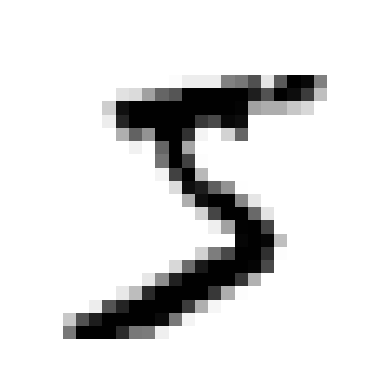

In [4]:
import matplotlib.pyplot as plt

def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap="binary")
    plt.axis("off")

some_digit = X[0]
plot_digit(some_digit)
print(y[0])

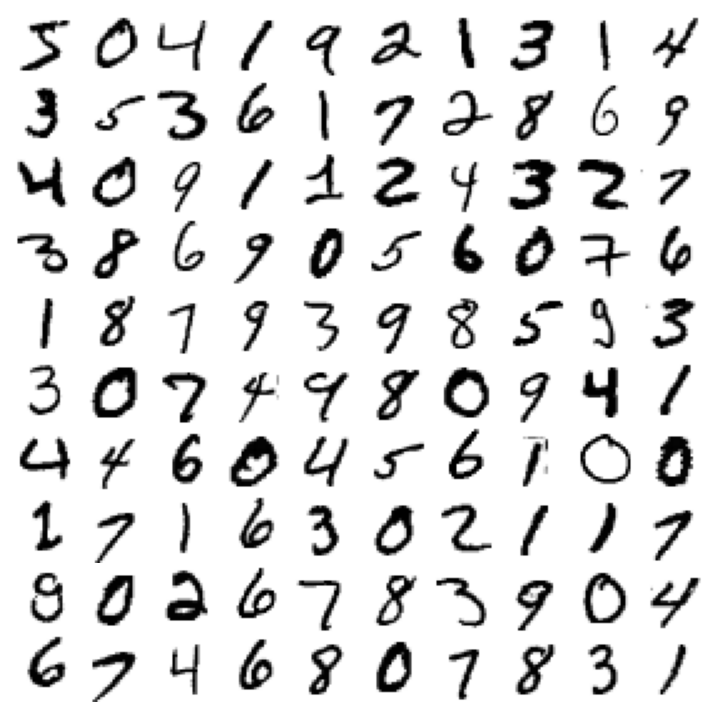

In [5]:
# first 100 samples
def plot_100(X):
    plt.figure(figsize=(9, 9))
    for idx, image_data in enumerate(X[:100]):
        plt.subplot(10, 10, idx + 1)
        plot_digit(image_data)
    plt.subplots_adjust(wspace=0, hspace=0)
plot_100(X)

In [6]:
from sklearn.model_selection import train_test_split

# To keep things manageable for demos, just sample 5% for training/testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, train_size=0.05,  random_state=42)

In [7]:
# double check
X_train.shape

(3500, 784)

# Multiclass Classification

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score

model = RandomForestClassifier()

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [9]:
print(model.predict(X[:10,:]))
print(y_train[:10])

['5' '0' '4' '1' '9' '2' '1' '3' '1' '4']
['1' '2' '6' '6' '5' '2' '5' '3' '3' '0']


In [10]:
# How does the cross validation look?
cross_val_score(model, X_train, y_train, cv=3, scoring="accuracy")

array([0.92287918, 0.92202228, 0.92281304])

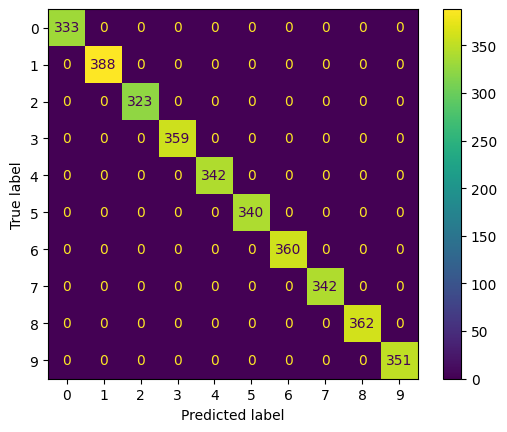

In [11]:
from sklearn.metrics import ConfusionMatrixDisplay

y_train_pred = model.predict(X_train)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred)
plt.show()

## Data augmentation


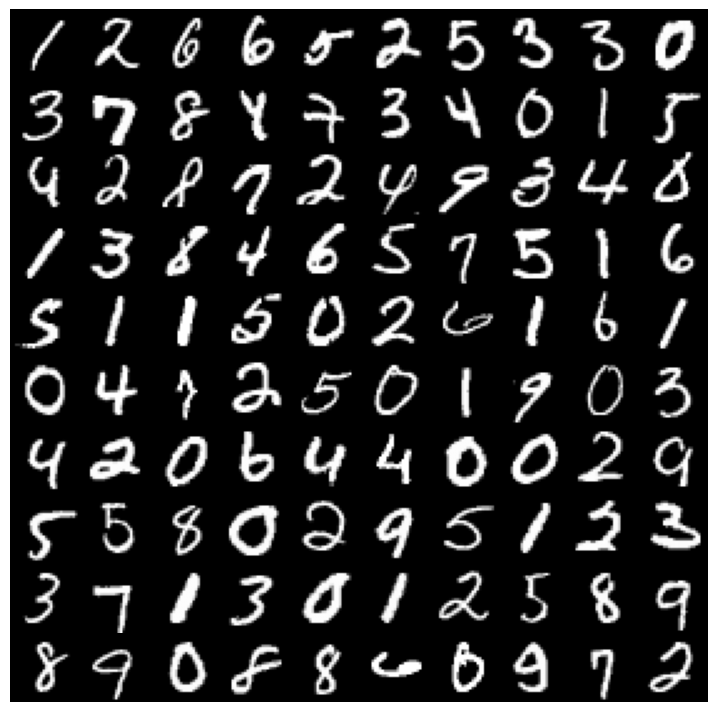

In [12]:
# For example, invert the data
X_train_inv = 255 - X_train

plot_100(X_train_inv)

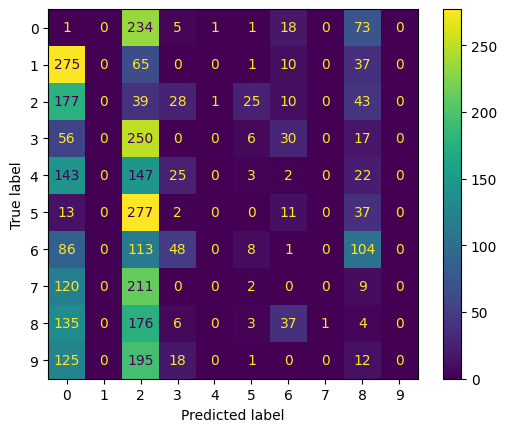

In [13]:
y_train_inv_pred = model.predict(X_train_inv)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_inv_pred)
plt.show()

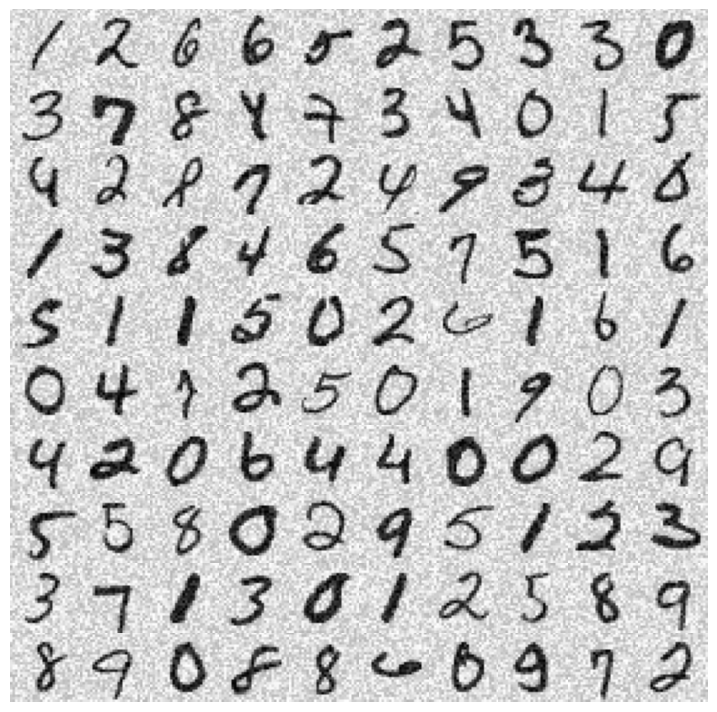

In [14]:
# what about noise?
import numpy as np
rng = np.random.default_rng(seed=42) 
noise_train = rng.integers(0, 100, (len(X_train), 784))
X_noise = X_train + noise_train

plot_100(X_noise)

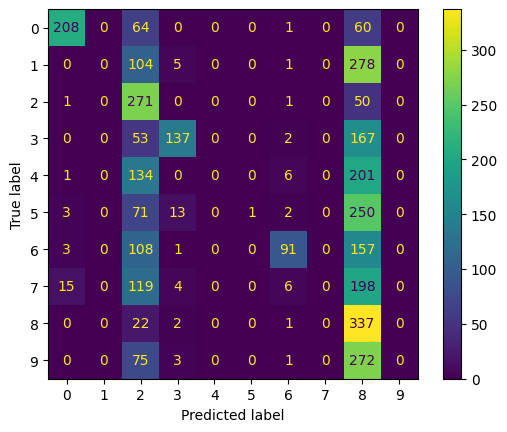

In [15]:
y_train_noise_pred = model.predict(X_noise)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_noise_pred)
plt.show()